## 3. Power Regression

### Theory

Power regression fits data that follows a power law relationship.

**Model Equation:**

$$y = a \cdot x^b$$

Where:
- $a$ = scaling constant
- $b$ = power exponent

**Linearization:**

Take natural logarithm of both sides:

$$\ln(y) = \ln(a) + b \cdot \ln(x)$$

Let:
- $Y = \ln(y)$
- $A = \ln(a)$
- $B = b$
- $X = \ln(x)$

Then the equation becomes linear:

$$Y = A + BX$$

**Transformed Normal Equations:**

$$B = \frac{n\sum \ln x \ln y - \sum \ln x \sum \ln y}{n\sum (\ln x)^2 - (\sum \ln x)^2}$$

$$A = \frac{\sum \ln y - B\sum \ln x}{n}$$

**Convert Back:**

$$a = e^{A}$$

$$b = B$$

**Algorithm:**

1. Transform data:
   - $\ln x_i = \ln(x_i)$
   - $\ln y_i = \ln(y_i)$
2. Apply linear regression to $(\ln x_i, \ln y_i)$:
   - $B = \frac{n\sum \ln x \ln y - \sum \ln x \sum \ln y}{n\sum (\ln x)^2 - (\sum \ln x)^2}$
   - $A = \frac{\sum \ln y - B\sum \ln x}{n}$
3. Convert back: $a = e^{A}$, $b = B$
4. Return $y = a \cdot x^b$

**Note:** $x$ values must be positive for $\ln(x)$ to be defined.

POWER LEAST SQUARE

Original data:
   x     y    ln(x)   ln(y)
----------------------------------------
    1     2.0    0.0000   0.6931
    2     8.0    0.6931   2.0794
    3    18.0    1.0986   2.8904
    4    32.0    1.3863   3.4657
    5    50.0    1.6094   3.9120
    6    72.0    1.7918   4.2767
    7    98.0    1.9459   4.5850
    8   128.0    2.0794   4.8520
    9   162.0    2.1972   5.0876
   10   200.0    2.3026   5.2983

RESULTS:
ln(y) = 0.6931 + 2.0000 * ln(x)

Fitted power curve: y = 2.0000 * x^2.0000
Or: y = 2.0000 * x^2.0000

R² = 1.000000 (1 = perfect fit)

PREDICTIONS:
   x     Actual    Predicted   Error
---------------------------------------------
    1      2.00      2.0000   -0.0000
    2      8.00      8.0000   -0.0000
    3     18.00     18.0000   -0.0000
    4     32.00     32.0000   -0.0000
    5     50.00     50.0000   -0.0000
    6     72.00     72.0000   -0.0000
    7     98.00     98.0000   -0.0000
    8    128.00    128.0000   -0.0000
    9    162.00    16

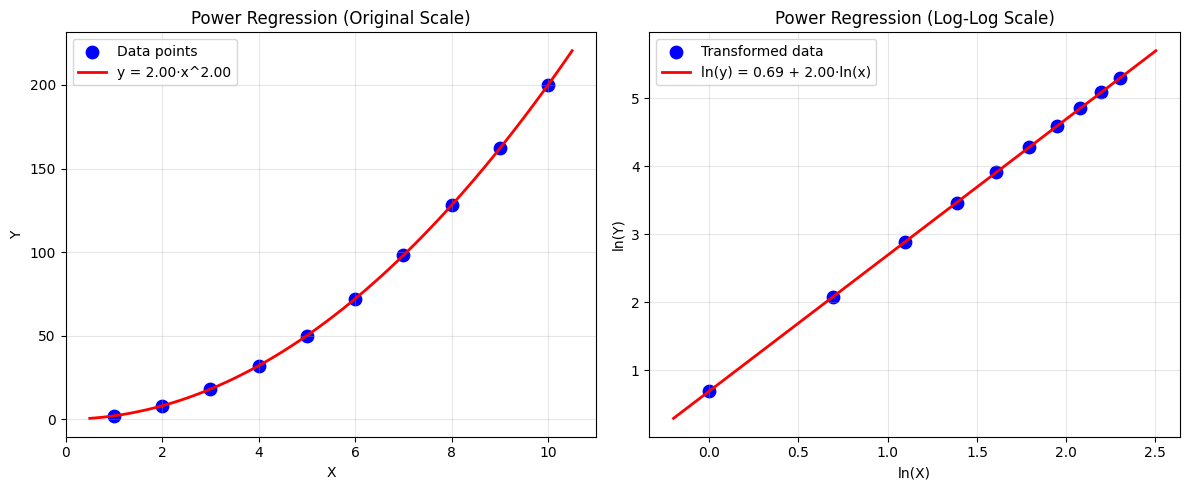

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Power Least Square
# Model: y = a * x^b
# Take ln both sides: ln(y) = ln(a) + b * ln(x)

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=np.float32)
y = np.array([2, 8, 18, 32, 50, 72, 98, 128, 162, 200], dtype=np.float32)  # y = 2*x²

n = len(x)

# Transform: take ln of x and y
ln_x = np.log(x)
ln_y = np.log(y)

print("=" * 50)
print("POWER LEAST SQUARE")
print("=" * 50)
print("\nOriginal data:")
print("   x     y    ln(x)   ln(y)")
print("-" * 40)
for i in range(n):
    print(f"{x[i]:5.0f}  {y[i]:6.1f}  {ln_x[i]:8.4f} {ln_y[i]:8.4f}")

# Calculate sums for linear regression on transformed data
sum_ln_x = 0
sum_ln_y = 0
sum_ln_x2 = 0
sum_ln_x_ln_y = 0

for i in range(n):
    sum_ln_x += ln_x[i]
    sum_ln_y += ln_y[i]
    sum_ln_x2 += ln_x[i]**2
    sum_ln_x_ln_y += ln_x[i] * ln_y[i]

# Calculate coefficients for ln(y) = ln(a) + b * ln(x)
# This is linear regression on transformed data
denominator = n * sum_ln_x2 - sum_ln_x * sum_ln_x
b = (n * sum_ln_x_ln_y - sum_ln_x * sum_ln_y) / denominator
ln_a = (sum_ln_y - b * sum_ln_x) / n
a = np.exp(ln_a)

print("\n" + "=" * 40)
print("RESULTS:")
print("=" * 40)
print(f"ln(y) = {ln_a:.4f} + {b:.4f} * ln(x)")
print(f"\nFitted power curve: y = {a:.4f} * x^{b:.4f}")
print(f"Or: y = {a:.4f} * x^{b:.4f}")

# Calculate predicted values
y_pred = a * (x ** b)

# Calculate R² (goodness of fit)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"\nR² = {r2:.6f} (1 = perfect fit)")

# Calculate errors
print("\n" + "=" * 40)
print("PREDICTIONS:")
print("=" * 40)
print("   x     Actual    Predicted   Error")
print("-" * 45)
for i in range(n):
    error = y[i] - y_pred[i]
    print(f"{x[i]:5.0f}  {y[i]:8.2f}  {y_pred[i]:10.4f}  {error:8.4f}")

# Plot
plt.figure(figsize=(12, 5))

# Plot 1: Original scale
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', s=80, label='Data points')
x_curve = np.linspace(min(x)-0.5, max(x)+0.5, 100)
y_curve = a * (x_curve ** b)
plt.plot(x_curve, y_curve, color='red', linewidth=2, 
         label=f'y = {a:.2f}·x^{b:.2f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Power Regression (Original Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Log-Log scale (should be a straight line)
plt.subplot(1, 2, 2)
plt.scatter(ln_x, ln_y, color='blue', s=80, label='Transformed data')
ln_x_line = np.linspace(min(ln_x)-0.2, max(ln_x)+0.2, 100)
ln_y_line = ln_a + b * ln_x_line
plt.plot(ln_x_line, ln_y_line, color='red', linewidth=2, 
         label=f'ln(y) = {ln_a:.2f} + {b:.2f}·ln(x)')
plt.xlabel('ln(X)')
plt.ylabel('ln(Y)')
plt.title('Power Regression (Log-Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()